In [38]:
import pandas as pd
df = pd.read_csv("makeup_sales_dataset_2025.csv")
df

,Sale_ID,Date,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_USD,Units_Sold,Revenue_USD
0,1,2025-11-24,Fenty Beauty,Eyeliner,UAE,Retail Store,Digital Wallet,17.80,48,854.40
1,2,2025-02-22,L'Oreal,Highlighter,USA,Online,Cash,82.82,35,2898.70
2,3,2025-04-22,Maybelline,Eyeliner,Germany,Retail Store,Card,31.76,39,1238.64
3,4,2025-10-29,MAC,Highlighter,France,Mall,Cash,36.99,1,36.99
4,5,2025-04-21,L'Oreal,Lipstick,Germany,Online,Card,115.08,22,2531.76
...,...,...,...,...,...,...,...,...,...,...
495,496,2025-09-25,L'Oreal,Highlighter,UAE,Beauty Salon,Card,84.15,40,3366.00
496,497,2025-12-06,MAC,Foundation,USA,Retail Store,Digital Wallet,82.77,25,2069.25
497,498,2025-08-29,L'Oreal,Eyeshadow,France,Retail Store,Card,102.97,11,1132.67
498,499,2025-05-23,NARS,Highlighter,UAE,Online,Card,10.79,15,161.85


Sale_ID           Axes(0.125,0.653529;0.227941x0.226471)
Price_USD      Axes(0.398529,0.653529;0.227941x0.226471)
Units_Sold     Axes(0.672059,0.653529;0.227941x0.226471)
Revenue_USD       Axes(0.125,0.381765;0.227941x0.226471)
dtype: object

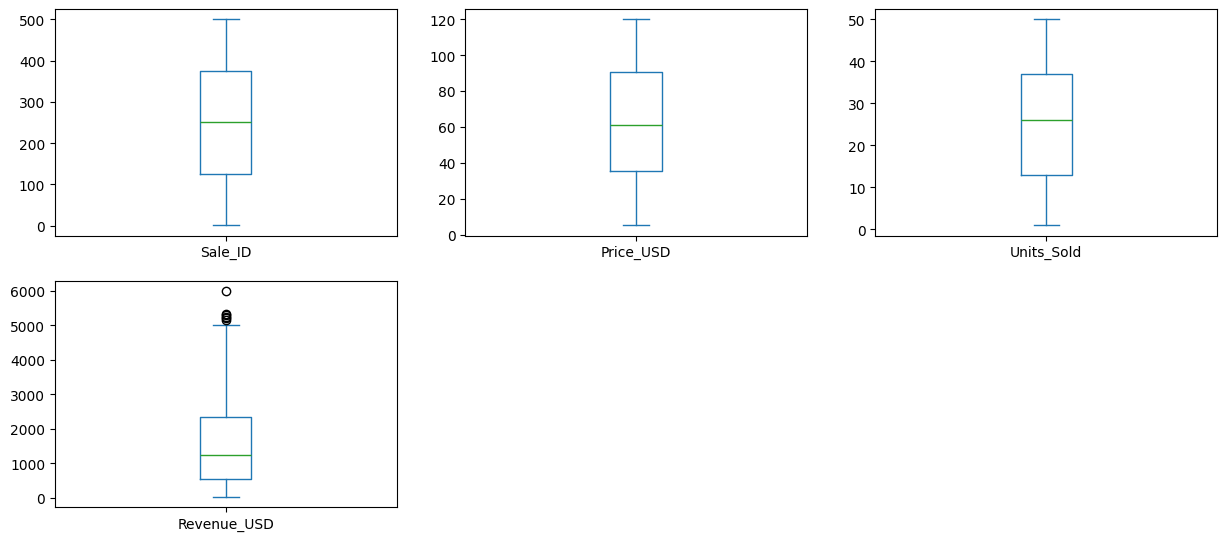

In [39]:
df.plot(kind="box",subplots=True,layout=(3,3),figsize=(15,10))

In [40]:
df.isnull().sum()

Sale_ID           0
Date              0
Brand             0
Product_Type      0
Country           0
Sales_Channel     0
Payment_Method    0
Price_USD         0
Units_Sold        0
Revenue_USD       0
dtype: int64

In [41]:
df.drop("Date",axis=1,inplace=True)

In [42]:
df.dtypes

Sale_ID             int64
Brand              object
Product_Type       object
Country            object
Sales_Channel      object
Payment_Method     object
Price_USD         float64
Units_Sold          int64
Revenue_USD       float64
dtype: object

In [43]:
df["Price_USD"]=df["Price_USD"]*90.75
df.rename(columns={"Price_USD":"Price_INR"},inplace=True)
df["Revenue_USD"]=df["Revenue_USD"]*90.75
df.rename(columns={"Revenue_USD":"Revenue_INR"},inplace=True)
df

,Sale_ID,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_INR,Units_Sold,Revenue_INR
0,1,Fenty Beauty,Eyeliner,UAE,Retail Store,Digital Wallet,1615.3500,48,77536.8000
1,2,L'Oreal,Highlighter,USA,Online,Cash,7515.9150,35,263057.0250
2,3,Maybelline,Eyeliner,Germany,Retail Store,Card,2882.2200,39,112406.5800
3,4,MAC,Highlighter,France,Mall,Cash,3356.8425,1,3356.8425
4,5,L'Oreal,Lipstick,Germany,Online,Card,10443.5100,22,229757.2200
...,...,...,...,...,...,...,...,...,...
495,496,L'Oreal,Highlighter,UAE,Beauty Salon,Card,7636.6125,40,305464.5000
496,497,MAC,Foundation,USA,Retail Store,Digital Wallet,7511.3775,25,187784.4375
497,498,L'Oreal,Eyeshadow,France,Retail Store,Card,9344.5275,11,102789.8025
498,499,NARS,Highlighter,UAE,Online,Card,979.1925,15,14687.8875


In [44]:
df.drop("Sale_ID",axis=1,inplace=True)

In [45]:
df

,Brand,Product_Type,Country,Sales_Channel,Payment_Method,Price_INR,Units_Sold,Revenue_INR
0,Fenty Beauty,Eyeliner,UAE,Retail Store,Digital Wallet,1615.3500,48,77536.8000
1,L'Oreal,Highlighter,USA,Online,Cash,7515.9150,35,263057.0250
2,Maybelline,Eyeliner,Germany,Retail Store,Card,2882.2200,39,112406.5800
3,MAC,Highlighter,France,Mall,Cash,3356.8425,1,3356.8425
4,L'Oreal,Lipstick,Germany,Online,Card,10443.5100,22,229757.2200
...,...,...,...,...,...,...,...,...
495,L'Oreal,Highlighter,UAE,Beauty Salon,Card,7636.6125,40,305464.5000
496,MAC,Foundation,USA,Retail Store,Digital Wallet,7511.3775,25,187784.4375
497,L'Oreal,Eyeshadow,France,Retail Store,Card,9344.5275,11,102789.8025
498,NARS,Highlighter,UAE,Online,Card,979.1925,15,14687.8875


In [46]:
#one hot encoding for categorical columns by sklearn
from sklearn.preprocessing import OneHotEncoder
def encode_categorical(df, column):
    encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    encoded = encoder.fit_transform(df[[column]])
    encoded_df = pd.DataFrame(
        encoded,
        columns=encoder.get_feature_names_out([column]),
        index=df.index
    ).astype(int)

    # Drop once, then concat
    df.drop(columns=[column], inplace=True)
    df[encoded_df.columns] = encoded_df

# calls
encode_categorical(df, "Brand")
encode_categorical(df, "Product_Type")
encode_categorical(df, "Country")
encode_categorical(df,"Sales_Channel")
encode_categorical(df,"Payment_Method")

In [47]:
df.dtypes

Price_INR                        float64
Units_Sold                         int64
Revenue_INR                      float64
Brand_Dior                         int64
Brand_Estee Lauder                 int64
Brand_Fenty Beauty                 int64
Brand_Huda Beauty                  int64
Brand_L'Oreal                      int64
Brand_MAC                          int64
Brand_Maybelline                   int64
Brand_NARS                         int64
Product_Type_Blush                 int64
Product_Type_Concealer             int64
Product_Type_Eyeliner              int64
Product_Type_Eyeshadow             int64
Product_Type_Foundation            int64
Product_Type_Highlighter           int64
Product_Type_Lipstick              int64
Product_Type_Mascara               int64
Country_Canada                     int64
Country_France                     int64
Country_Germany                    int64
Country_India                      int64
Country_Saudi Arabia               int64
Country_UAE     

In [48]:
df

,Price_INR,Units_Sold,Revenue_INR,Brand_Dior,Brand_Estee Lauder,Brand_Fenty Beauty,Brand_Huda Beauty,Brand_L'Oreal,Brand_MAC,Brand_Maybelline,...,Country_UAE,Country_UK,Country_USA,Sales_Channel_Beauty Salon,Sales_Channel_Mall,Sales_Channel_Online,Sales_Channel_Retail Store,Payment_Method_Card,Payment_Method_Cash,Payment_Method_Digital Wallet
0,1615.3500,48,77536.8000,0,0,1,0,0,0,0,...,1,0,0,0,0,0,1,0,0,1
1,7515.9150,35,263057.0250,0,0,0,0,1,0,0,...,0,0,1,0,0,1,0,0,1,0
2,2882.2200,39,112406.5800,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,1,0,0
3,3356.8425,1,3356.8425,0,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,1,0
4,10443.5100,22,229757.2200,0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,7636.6125,40,305464.5000,0,0,0,0,1,0,0,...,1,0,0,1,0,0,0,1,0,0
496,7511.3775,25,187784.4375,0,0,0,0,0,1,0,...,0,0,1,0,0,0,1,0,0,1
497,9344.5275,11,102789.8025,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,1,0,0
498,979.1925,15,14687.8875,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0,1,0,0


In [49]:

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

X = df.drop("Revenue_INR", axis=1)
y = df["Revenue_INR"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("accuracy:", model.score(X_test, y_test))

accuracy: 0.8619666388273933


In [50]:
#training and testing accuracy
print("Training Accuracy:", model.score(X_train, y_train))
print("Testing Accuracy:", model.score(X_test, y_test))

Training Accuracy: 0.8845691742843982
Testing Accuracy: 0.8619666388273933
